---
---
## Parte 03 - Comparação entre Modelo A e Modelo B

Este notebook compara o **Modelo A**, atualmente em produção, com o **Modelo B**, candidato à substituição. A pergunta central é:

> **Devemos trocar o Modelo A pelo Modelo B?**

A comparação respeita um ponto essencial do desenho experimental: os dois modelos foram avaliados nos **mesmos 5.000 chamados**. Portanto, as predições são pareadas e não devem ser tratadas como amostras independentes.

O notebook está organizado em quatro blocos:

1. **Desempenho global com incerteza:** comparação das métricas principais com bootstrap pareado estratificado e teste de McNemar.
2. **Comparação por categoria:** verificação de ganhos e perdas em `categoria_real`, evitando recomendar troca apenas por média global.
3. **Erros, confiança e calibração:** comparação das matrizes de confusão, da confiança declarada e das curvas de calibração aproximada.
4. **Robustez por subgrupos:** avaliação de ganhos por `canal`, `faixa_tamanho_texto` e `bairro`.

A decisão final considera não apenas o ganho médio, mas também os <u>riscos operacionais de troca</u>, especialmente quando há piora localizada em alguma categoria.

---
---


### **Preparação do Ambiente e dos Dados**

#### **Importação de Pacotes e Configurações**


In [ ]:
# Importa bibliotecas de manipulação, visualização, estatística e avaliação de classificadores.
from pathlib import Path
from typing import Any, Dict, List, Optional, Sequence, Tuple, Union
import warnings

import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display
from sklearn.metrics import confusion_matrix
from statsmodels.stats.contingency_tables import mcnemar
from statsmodels.stats.multitest import multipletests

from functions import (
    calcular_metricas_globais,
    gerar_amostra_bootstrap_estratificada,
    load_and_prepare_data,
    pretty_label,
    save_figure,
    save_table,
)

warnings.filterwarnings("ignore")

In [12]:
# Define tema visual, resolução das figuras e diretórios de saída.
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.dpi"] = 120
plt.rcParams["savefig.dpi"] = 180
plt.rcParams["axes.titlesize"] = 13
plt.rcParams["axes.labelsize"] = 11

# Define diretórios padronizados para salvar figuras e tabelas desta etapa.
output_dir = Path("../results")
fig_dir = output_dir / "figures/comparacao_de_modelos"
tab_dir = output_dir / "tables/comparacao_de_modelos"
fig_dir.mkdir(parents=True, exist_ok=True)
tab_dir.mkdir(parents=True, exist_ok=True)


#### **Leitura da Base e Criação das Variáveis de Comparação**

**Objetivo:** Criar indicadores binários de acerto para os dois modelos.

**Metodologia:** para cada chamado, comparamos `categoria_real` com `pred_modelo_a` e `pred_modelo_b`. Então, criamos colunas que indicam:
- quando ambos acertam;
- ambos erram;
- quando apenas o Modelo A acerta e quando apenas o Modelo B acerta.

**Importância:** essas variáveis são a base do <u>teste pareado de McNemar</u> e da análise de ganho líquido entre os modelos.

---


In [13]:
# Carrega a base sintética de chamados e aplica os tratamentos padronizados do projeto.
path = Path("../dados/chamados_com_predicoes.csv")
df = load_and_prepare_data(path)

# Define parâmetros globais de incerteza e reprodutibilidade.
n_bootstrap = 1000
seed = 42
alpha = 0.05

# Padroniza as predições para evitar diferenças artificiais por espaços extras.
df["pred_modelo_a"] = df["pred_modelo_a"].astype(str).str.strip()
df["pred_modelo_b"] = df["pred_modelo_b"].astype(str).str.strip()

# Cria faixas de tamanho textual para avaliar se o ganho do Modelo B depende do volume de informação no texto.
df["faixa_tamanho_texto"] = pd.qcut(
    df["palavra_count"],
    q=4,
    labels=[
        "Textos mais curtos",
        "Textos médio-curtos",
        "Textos médio-longos",
        "Textos mais longos",
    ],
    duplicates="drop",
)

# Cria faixas de confiança para comparar calibração aproximada entre os modelos.
df["faixa_confianca_a"] = pd.cut(df["conf_modelo_a"], bins=np.linspace(0, 1, 11), include_lowest=True)
df["faixa_confianca_b"] = pd.cut(df["conf_modelo_b"], bins=np.linspace(0, 1, 11), include_lowest=True)

# Ordena as classes por frequência real, mantendo consistência entre tabelas, matrizes e gráficos.
classes = df["categoria_real"].value_counts().sort_values(ascending=False).index.tolist()

# Cria indicadores pareados de acerto e erro para os dois modelos.
df_comp = df.copy()
df_comp["acerto_modelo_a"] = df_comp["categoria_real"] == df_comp["pred_modelo_a"]
df_comp["acerto_modelo_b"] = df_comp["categoria_real"] == df_comp["pred_modelo_b"]
df_comp["erro_modelo_a"] = ~df_comp["acerto_modelo_a"]
df_comp["erro_modelo_b"] = ~df_comp["acerto_modelo_b"]

# Classifica a relação de acerto entre os modelos em cada chamado.
df_comp["ambos_acertam"] = df_comp["acerto_modelo_a"] & df_comp["acerto_modelo_b"]
df_comp["ambos_erram"] = ~df_comp["acerto_modelo_a"] & ~df_comp["acerto_modelo_b"]
df_comp["a_acerta_b_erra"] = df_comp["acerto_modelo_a"] & ~df_comp["acerto_modelo_b"]
df_comp["b_acerta_a_erra"] = ~df_comp["acerto_modelo_a"] & df_comp["acerto_modelo_b"]


### **1. Desempenho Global com Incerteza**

#### **1.1 Métricas Globais com Bootstrap Pareado Estratificado**

**Objetivo:** Comparar o desempenho global dos Modelos A e B em `categoria_real`, reportando a diferença `Modelo B - Modelo A` com intervalo de confiança de 95%.

**Metodologia:** Usamos bootstrap pareado estratificado por `categoria_real`. Em cada repetição, reamostramos chamados com reposição dentro de cada categoria, preservando aproximadamente o desbalanceamento original da base. Para cada amostra, recalculamos as métricas dos dois modelos e armazenamos:

$$
\Delta_m = m(\text{Modelo B}) - m(\text{Modelo A})
$$

Os intervalos de confiança são obtidos pelos percentis 2,5% e 97,5% da distribuição bootstrap de $\Delta_m$.

- **Por que esse método?** Bootstrap pareado respeita que as duas predições pertencem aos mesmos chamados. A estratificação por `categoria_real` evita que categorias maiores dominem artificialmente a incerteza estimada.

**Importância:** como a base é desbalanceada, novamente priorizamos **Recall Macro** (acurácia desbalanceada), **F1 Macro**, **Kappa de Cohen** e **Coeficiente de Matthews**.

---


In [14]:
# Função para formatar estimativas com intervalo de confiança.
def formatar_ic(valor: float, inf: float, sup: float, casas: int = 3) -> str:
    """Formata uma estimativa pontual com intervalo de confiança.
    A saída facilita a leitura de tabelas comparativas.
    """
    return f"{valor:.{casas}f} [{inf:.{casas}f}, {sup:.{casas}f}]"


# Função para comparar métricas globais dos modelos usando bootstrap pareado estratificado.
def comparar_metricas_globais_bootstrap(
    df: pd.DataFrame,
    labels: Sequence[Any],
    n_bootstrap: int = 1000,
    alpha: float = 0.05,
    seed: int = 42,
) -> Tuple[pd.DataFrame, pd.DataFrame]:
    """Calcula métricas globais dos dois modelos e IC bootstrap para o delta B-A.
    O bootstrap é estratificado por categoria real para preservar o desenho da base.
    """
    metricas_a = calcular_metricas_globais(df["categoria_real"], df["pred_modelo_a"], labels)
    metricas_b = calcular_metricas_globais(df["categoria_real"], df["pred_modelo_b"], labels)

    rng = np.random.default_rng(seed)
    resultados_boot: List[Dict[str, float]] = []

    # Reamostra chamados dentro de cada categoria real e recalcula as diferenças de métricas.
    for _ in range(n_bootstrap):
        amostra = gerar_amostra_bootstrap_estratificada(df, coluna_estrato="categoria_real", rng=rng)
        boot_a = calcular_metricas_globais(amostra["categoria_real"], amostra["pred_modelo_a"], labels)
        boot_b = calcular_metricas_globais(amostra["categoria_real"], amostra["pred_modelo_b"], labels)

        for metrica in metricas_a:
            resultados_boot.append({
                "metrica": metrica,
                "delta_b_menos_a": boot_b[metrica] - boot_a[metrica],
            })

    boot = pd.DataFrame(resultados_boot)
    linhas: List[Dict[str, float]] = []

    # Resume estimativa pontual, intervalo de confiança e dispersão bootstrap para cada métrica.
    for metrica in metricas_a:
        dist = boot.loc[boot["metrica"] == metrica, "delta_b_menos_a"]
        linhas.append({
            "Métrica": metrica,
            "Modelo A": metricas_a[metrica],
            "Modelo B": metricas_b[metrica],
            "Δ(B-A)": metricas_b[metrica] - metricas_a[metrica],
            "Δ IC Inf. (95%)": dist.quantile(alpha / 2),
            "Δ IC Sup. (95%)": dist.quantile(1 - alpha / 2),
            "Δ Desvio Bootstrap": dist.std(),
        })

    return pd.DataFrame(linhas), boot

In [15]:
# Calcula a tabela global comparando Modelo A e Modelo B.
tabela_global_ab, bootstrap_global_ab = comparar_metricas_globais_bootstrap(
    df_comp, labels=classes, n_bootstrap=n_bootstrap, alpha=alpha, seed=seed)

display(tabela_global_ab)
save_table(tabela_global_ab, tab_dir, "07_comparacao_global_modelo_a_vs_b_bootstrap")

,Métrica,Modelo A,Modelo B,Δ(B-A),Δ IC Inf. (95%),Δ IC Sup. (95%),Δ Desvio Bootstrap
0,Acurácia,0.772800,0.867600,0.094800,0.080795,0.109605,0.007232
1,Precisão Macro,0.774338,0.859602,0.085264,0.068349,0.101792,0.008540
2,Recall Macro,0.770992,0.852288,0.081296,0.064014,0.099624,0.008564
3,F1 Macro,0.770438,0.851562,0.081124,0.064769,0.097810,0.008306
4,Precisão Ponderada,0.777637,0.866086,0.088449,0.073711,0.103423,0.007361
5,Recall Ponderada,0.772800,0.867600,0.094800,0.080795,0.109605,0.007232
6,F1 Ponderada,0.772524,0.863572,0.091048,0.076800,0.105771,0.007378
7,Kappa de Cohen,0.732224,0.843693,0.111469,0.094769,0.128991,0.008540
8,Coeficiente de Matthews,0.733362,0.844336,0.110974,0.094345,0.128358,0.008507


PosixPath('../results/tables/comparacao_de_modelos/07_comparacao_global_modelo_a_vs_b_bootstrap.csv')

**<u>Resultados</u>:**

- O Modelo B melhora todas as métricas globais avaliadas.

- A `Acurácia` sobe de **0,77** no Modelo A para **0,86** no Modelo B, ganho de **0,0948** ou **9,48 pontos percentuais**.

- O `F1 Macro` sobe de **0,77** para **0,85**, ganho de **0,08**, com IC 95% de **[0,0648; 0,0978]**. Como o intervalo está totalmente acima de zero, o ganho é estatisticamente consistente.

- O `Kappa de Cohen` sobe de **0,73** para **0,84**, ganho de **0,11**, com IC 95% de **[0,0948; 0,1290]**.

- O `Coeficiente de Matthews` sobe de **0,73** para **0,84**, ganho de **0,11**, com IC 95% de **[0,0943; 0,1284]**.

⟹ A evidência global favorece o Modelo B. Agora falta verificar se esse ganho médio se sustenta por `categoria_real`, pois a troca é arriscada se piorar uma categoria operacionalmente importante.

---

#### **1.2 Diferença Global das Métricas com IC 95%**

**Objetivo:** visualizar o ganho do Modelo B em relação ao Modelo A nas principais métricas.

**Metodologia:** plotamos $\Delta = \text{Modelo B} - \text{Modelo A}$ para cada métrica, com barras horizontais representando o IC 95% bootstrap.\
A linha vertical em zero representa ausência de diferença entre os modelos.

**Interpretação:** pontos à direita de zero indicam vantagem do Modelo B. Se o intervalo de confiança não cruza zero, o ganho é mais estável sob reamostragem.

**Importância:** esse gráfico resume a direção e a incerteza do ganho global, evitando depender apenas da estimativa pontual.



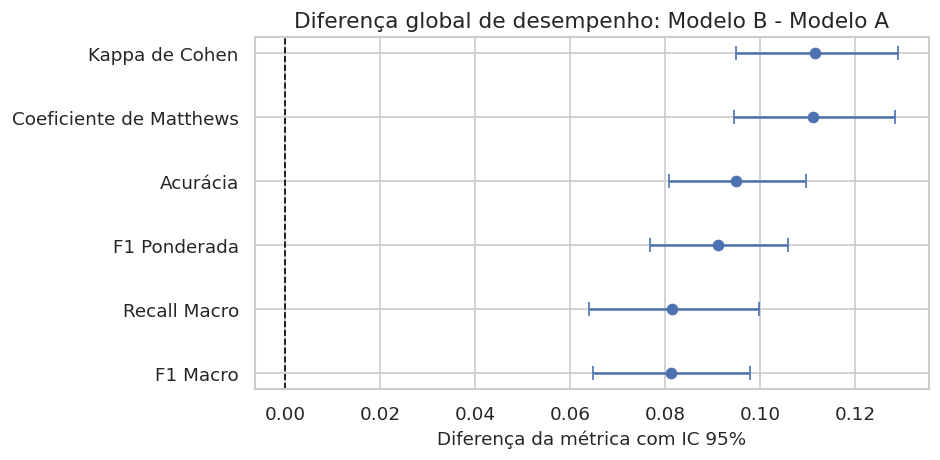

In [16]:
# Seleciona métricas principais para o gráfico de diferenças globais.
metricas_principais = ["Acurácia", "Recall Macro", "F1 Macro", "F1 Ponderada", "Kappa de Cohen", "Coeficiente de Matthews"]

dados_plot = (tabela_global_ab.loc[tabela_global_ab["Métrica"].isin(metricas_principais)].copy().sort_values("Δ(B-A)"))

fig, ax = plt.subplots(figsize=(8, 4))
# Plota a estimativa pontual e o intervalo de confiança bootstrap para o delta B-A.
ax.errorbar(dados_plot["Δ(B-A)"], dados_plot["Métrica"], 
    xerr=[dados_plot["Δ(B-A)"] - dados_plot["Δ IC Inf. (95%)"],
          dados_plot["Δ IC Sup. (95%)"] - dados_plot["Δ(B-A)"]],
    fmt="o", capsize=4)

# Linha de referência: valores à direita favorecem o Modelo B.
ax.axvline(0, color="black", linewidth=1, linestyle="--")
ax.set_title("Diferença global de desempenho: Modelo B - Modelo A")
ax.set_xlabel("Diferença da métrica com IC 95%")
ax.set_ylabel("")
save_figure(fig, fig_dir, "07_diferenca_metricas_globais_modelo_b_menos_a")


**<u>Resultados</u>:**

- Todas as diferenças globais ficam à direita de zero, indicando vantagem do Modelo B.

- Os intervalos de confiança de `Acurácia`, `Recall Macro`, `F1 Macro`, `Kappa de Cohen` e `Coeficiente de Matthews` não cruzam zero.

- O ganho é maior nas métricas de concordância global ajustada (`Kappa de Cohen` e `Coeficiente de Matthews`), com incremento ≈ **0,11**.

⟹ O Modelo B não apenas acerta mais chamados, mas também melhora medidas que penalizam erros estruturados e são mais robustas ao desbalanceamento das categorias.

---

#### **1.3 Teste de McNemar para Acurácia Pareada**

**Objetivo:** testar se o ganho de acurácia do Modelo B é estatisticamente significativo considerando que os dois modelos foram avaliados nos mesmos chamados.

**Metodologia:** usamos o teste de McNemar, apropriado para comparar dois classificadores em dados pareados com resposta binária de acerto/erro. O teste olha apenas os casos discordantes:

- `a_acerta_b_erra`: chamados em que o Modelo A acerta e o Modelo B erra;
- `b_acerta_a_erra`: chamados em que o Modelo B acerta e o Modelo A erra.

A hipótese nula é:

$$
H_0: P(A\text{ acerta}, B\text{ erra}) = P(B\text{ acerta}, A\text{ erra})
$$

- $H_0$: Não há assimetria relevante entre os modelos: as trocas de acerto e erro aconteceriam na mesma proporção.
- $H_1$: Existe assimetria, isto é, um modelo corrige mais erros do outro do que o contrário.

⟹ Se `ganho_liquido_b` (casos que o B corrige do A menos casos que o B passa a errar) for positivo e o p-valor for pequeno, há evidência de que o Modelo B melhora a acurácia pareada.

**Importância:** esse teste é mais adequado do que comparar acurácias como amostras independentes, porque cada chamado tem duas predições relacionadas.



In [17]:
# Função para aplicar o teste de McNemar a dois vetores pareados de acerto.
def executar_mcnemar(acerto_a: pd.Series, acerto_b: pd.Series) -> Dict[str, Union[int, float, str]]:
    """Executa o teste de McNemar para comparar acertos pareados dos modelos.
    Retorna a tabela de discordâncias, estatística, p-valor e ganho líquido do Modelo B.
    """
    ambos_acertam = int((acerto_a & acerto_b).sum())
    ambos_erram = int((~acerto_a & ~acerto_b).sum())
    a_acerta_b_erra = int((acerto_a & ~acerto_b).sum())
    b_acerta_a_erra = int((~acerto_a & acerto_b).sum())

    # Tabela 2x2 pareada: somente os elementos fora da diagonal determinam o teste.
    tabela = np.array([
        [ambos_acertam, a_acerta_b_erra],
        [b_acerta_a_erra, ambos_erram],
    ])

    n_discordantes = a_acerta_b_erra + b_acerta_a_erra

    if n_discordantes == 0:
        return {
            "Ambos Acertam": ambos_acertam,
            "Ambos Erram": ambos_erram,
            "A acerta, B erra": a_acerta_b_erra,
            "B acerta, A erra": b_acerta_a_erra,
            "n Discordantes": n_discordantes,
            "Estatística": np.nan,
            "P-valor": 1.0,
            "Método": "Sem casos discordantes",
            "Ganho Líquido B": 0,
        }

    # Usa teste exato quando há poucos discordantes; caso contrário, aproximação qui-quadrado com correção.
    usar_exato = n_discordantes <= 50
    resultado = mcnemar(tabela, exact=usar_exato, correction=not usar_exato)

    return {
        "Ambos Acertam": ambos_acertam,
        "Ambos Erram": ambos_erram,
        "A acerta, B erra": a_acerta_b_erra,
        "B acerta, A erra": b_acerta_a_erra,
        "n Discordantes": n_discordantes,
        "Estatistica": resultado.statistic,
        "P-valor": resultado.pvalue,
        "Método": "McNemar Exato" if usar_exato else "McNemar qui-quadrado com correção de continuidade",
        "Ganho Líquido B": b_acerta_a_erra - a_acerta_b_erra,
    }

In [18]:
# Aplica o teste global para a comparação pareada de acurácia.
resultado_mcnemar_global = executar_mcnemar(df_comp["acerto_modelo_a"], df_comp["acerto_modelo_b"])
tabela_mcnemar_global = pd.DataFrame([resultado_mcnemar_global])

display(tabela_mcnemar_global)
save_table(tabela_mcnemar_global, tab_dir, "07_teste_mcnemar_global_modelo_a_vs_b")

,Ambos Acertam,Ambos Erram,"A acerta, B erra","B acerta, A erra",n Discordantes,Estatistica,P-valor,Método,Ganho Líquido B
0,3347,145,517,991,1508,148.361406,3.954851e-34,McNemar qui-quadrado com correção de continuidade,474


PosixPath('../results/tables/comparacao_de_modelos/07_teste_mcnemar_global_modelo_a_vs_b.csv')

**<u>Resultados</u>:**

- A diferença de acurácia entre os modelos é de **≈0,095**, equivalente a **474 acertos líquidos adicionais** do Modelo B em uma base de **5.000 chamados**.
- A tabela acima explicita quantos casos caem em `a_acerta_b_erra` e `b_acerta_a_erra`.
- O p-valor do teste de McNemar testa se essa assimetria poderia ser explicada por acaso. Quando o p-valor é menor que **0,05**, rejeitamos $H_0$ e concluímos que há evidência estatística de diferença pareada entre os modelos.

⟹ Como o ganho líquido global do Modelo B é grande e as métricas bootstrap também têm IC 95% inteiramente positivo, a evidência global favorece a troca. A decisão final, porém, ainda depende da análise por categoria.

---

[trocar aqui]

### **2. Comparação por Categoria**

#### **2.1 Métricas por Categoria e Teste Pareado de Recall**

**Objetivo:** verificar se o ganho global do Modelo B se sustenta quando olhamos cada `categoria_real` separadamente.

**Metodologia:** para cada categoria, tratamos a classe como problema binário “categoria versus demais categorias” e calculamos `Precisão`, `Recall` e `F1` para cada modelo. Também aplicamos McNemar dentro de cada categoria real para testar mudança no recall. Neste recorte estamos perguntando:

> Entre os chamados que realmente pertencem a esta categoria, o Modelo B acerta mais do que o Modelo A?

Como são feitos vários testes, aplicamos ajuste <u>Benjamini-Hochberg</u> nos p-valores para controlar a taxa esperada de falsos descobrimentos.

**Importância:** um modelo pode melhorar globalmente e ainda piorar uma categoria específica.

---


In [19]:
# Função para calcular métricas de uma categoria tratada como classe positiva.
def metricas_binarias_categoria(df: pd.DataFrame, categoria: Any, coluna_pred: str) -> Dict[str, Union[int, float]]:
    """Calcula TP, FP, FN, TN, precisão, recall e F1 para uma categoria.
    A categoria é tratada como classe positiva contra todas as demais.
    """
    real_pos = df["categoria_real"] == categoria
    pred_pos = df[coluna_pred] == categoria

    tp = int((real_pos & pred_pos).sum())
    fp = int((~real_pos & pred_pos).sum())
    fn = int((real_pos & ~pred_pos).sum())
    tn = int((~real_pos & ~pred_pos).sum())

    suporte_real = tp + fn
    suporte_predito = tp + fp
    precisao = tp / suporte_predito if suporte_predito > 0 else np.nan
    recall = tp / suporte_real if suporte_real > 0 else np.nan
    f1 = (
        2 * precisao * recall / (precisao + recall)
        if pd.notna(precisao) and pd.notna(recall) and precisao + recall > 0
        else np.nan
    )

    return {
        "tp": tp,
        "fp": fp,
        "fn": fn,
        "tn": tn,
        "suporte_real": suporte_real,
        "suporte_predito": suporte_predito,
        "Precisão": precisao,
        "Recall": recall,
        "F1": f1,
    }


# Função para montar tabela comparativa de métricas por categoria.
def comparar_por_categoria(df: pd.DataFrame, labels: Sequence[Any]) -> pd.DataFrame:
    """Compara Modelo A e B por categoria e aplica McNemar no recall pareado.
    Retorna deltas de precisão, recall, F1 e p-valores ajustados.
    """
    linhas: List[Dict[str, Any]] = []

    for categoria in labels:
        met_a = metricas_binarias_categoria(df, categoria, "pred_modelo_a")
        met_b = metricas_binarias_categoria(df, categoria, "pred_modelo_b")

        # Para recall, restringimos aos casos cuja categoria real é a categoria avaliada.
        subset_real = df[df["categoria_real"] == categoria]
        teste_recall = executar_mcnemar(subset_real["acerto_modelo_a"], subset_real["acerto_modelo_b"])

        linhas.append({
            "categoria_real": categoria,
            "Categoria": pretty_label(categoria),
            "Suporte Real": met_a["suporte_real"],
            "Suporte Predito A": met_a["suporte_predito"],
            "Suporte Predito B": met_b["suporte_predito"],
            "Precisão A": met_a["Precisão"],
            "Precisão B": met_b["Precisão"],
            "Δ Precisão (B-A)": met_b["Precisão"] - met_a["Precisão"],
            "Recall A": met_a["Recall"],
            "Recall B": met_b["Recall"],
            "Δ Recall (B-A)": met_b["Recall"] - met_a["Recall"],
            "F1 A": met_a["F1"],
            "F1 B": met_b["F1"],
            "Δ F1 (B-A)": met_b["F1"] - met_a["F1"],
            "A_acerta_B_erra_na_categoria": teste_recall["A acerta, B erra"],
            "B_acerta_A_erra_na_categoria": teste_recall["B acerta, A erra"],
            "ganho_liquido_B_na_categoria": teste_recall["Ganho Líquido B"],
            "P-valor McNemar Recall": teste_recall["P-valor"],
            "Método McNemar Recall": teste_recall["Método"],
        })

    tabela = pd.DataFrame(linhas)

    # Ajusta p-valores dos testes por categoria para múltiplas comparações.
    tabela["p_valor_mcnemar_recall_ajustado_bh"] = multipletests(
        tabela["P-valor McNemar Recall"].fillna(1),
        method="fdr_bh")[1]

    return tabela.sort_values("Suporte Real", ascending=False)


# Função para estimar IC dos deltas de métricas por categoria via bootstrap estratificado.
def bootstrap_deltas_categoria(
    df: pd.DataFrame,
    labels: Sequence[Any],
    n_bootstrap: int = 1000,
    alpha: float = 0.05,
    seed: int = 42,
) -> Tuple[pd.DataFrame, pd.DataFrame]:
    """Calcula intervalos bootstrap para deltas de precisão, recall e F1 por categoria.
    A reamostragem preserva a composição de categorias reais.
    """
    rng = np.random.default_rng(seed)
    linhas: List[Dict[str, Any]] = []

    for _ in range(n_bootstrap):
        amostra = gerar_amostra_bootstrap_estratificada(df, coluna_estrato="categoria_real", rng=rng)

        for categoria in labels:
            met_a = metricas_binarias_categoria(amostra, categoria, "pred_modelo_a")
            met_b = metricas_binarias_categoria(amostra, categoria, "pred_modelo_b")

            linhas.append({
                "categoria_real": categoria,
                "Δ Precisão (B-A)": met_b["Precisão"] - met_a["Precisão"],
                "Δ Recall (B-A)": met_b["Recall"] - met_a["Recall"],
                "Δ F1 (B-A)": met_b["F1"] - met_a["F1"]})

    boot = pd.DataFrame(linhas)
    resumo = (
        boot.groupby("categoria_real")
        .agg(
            delta_precision_ic95_inf=("Δ Precisão (B-A)", lambda x: x.quantile(alpha / 2)),
            delta_precision_ic95_sup=("Δ Precisão (B-A)", lambda x: x.quantile(1 - alpha / 2)),
            delta_recall_ic95_inf=("Δ Recall (B-A)", lambda x: x.quantile(alpha / 2)),
            delta_recall_ic95_sup=("Δ Recall (B-A)", lambda x: x.quantile(1 - alpha / 2)),
            delta_f1_ic95_inf=("Δ F1 (B-A)", lambda x: x.quantile(alpha / 2)),
            delta_f1_ic95_sup=("Δ F1 (B-A)", lambda x: x.quantile(1 - alpha / 2)))
        .reset_index())

    return resumo, boot


In [20]:
# Calcula métricas por categoria e intervalos de confiança bootstrap dos deltas.
tabela_categoria_ab = comparar_por_categoria(df_comp, classes)
ic_categoria_ab, bootstrap_categoria_ab = bootstrap_deltas_categoria(
    df_comp,
    labels=classes,
    n_bootstrap=n_bootstrap,
    alpha=alpha,
    seed=seed,
)

tabela_categoria_ab = tabela_categoria_ab.merge(ic_categoria_ab, on="categoria_real", how="left")

display(tabela_categoria_ab.head(3))
save_table(tabela_categoria_ab, tab_dir, "07_comparacao_por_categoria_modelo_a_vs_b")


,categoria_real,Categoria,Suporte Real,Suporte Predito A,Suporte Predito B,Precisão A,Precisão B,Δ Precisão (B-A),Recall A,Recall B,...,ganho_liquido_B_na_categoria,P-valor McNemar Recall,Método McNemar Recall,p_valor_mcnemar_recall_ajustado_bh,delta_precision_ic95_inf,delta_precision_ic95_sup,delta_recall_ic95_inf,delta_recall_ic95_sup,delta_f1_ic95_inf,delta_f1_ic95_sup
0,iluminacao_publica,Iluminação Publica,1143,1057,1162,0.857143,0.882960,0.025818,0.792651,0.897638,...,120,1.026213e-11,McNemar qui-quadrado com correção de continuidade,2.736568e-11,0.000085,0.050789,0.076990,0.132108,0.046502,0.087243
1,buraco_via,Buraco Via,908,1117,956,0.664279,0.871339,0.207060,0.817181,0.917401,...,91,1.189621e-09,McNemar qui-quadrado com correção de continuidade,1.903394e-09,0.180636,0.234220,0.070485,0.132159,0.139147,0.183622
2,coleta_lixo,Coleta Lixo,806,798,839,0.814536,0.880810,0.066274,0.806452,0.916873,...,89,2.941880e-10,McNemar qui-quadrado com correção de continuidade,5.883760e-10,0.036380,0.097215,0.078164,0.142680,0.062702,0.113242


PosixPath('../results/tables/comparacao_de_modelos/07_comparacao_por_categoria_modelo_a_vs_b.csv')

**<u>Resultados</u>:**

- O ganho global do Modelo B não é perfeitamente homogêneo por `categoria_real`.

- O maior ganho de `Recall` ocorre em `esgoto_vazamento`: a diferença é de ≈ **+0,31**, elevando o recall de ≈ **0,58** para ≈ **0,89**. Isso corrige uma fragilidade importante identificada no Modelo A.

- `buraco_via` também melhora de forma relevante: `Δ Precisão (B-A)` é ≈ **+0,20** e `Δ Recall (B-A)` é ≈ **+0,10**.

- O principal risco está em `poda_arvore`: `Δ Recall (B-A)` é ≈ **-0,25** e `Δ F1 (B-A)` é ≈ **-0,15**. O Modelo B deixa de recuperar uma parcela importante dos chamados reais dessa categoria.


#### **2.2 Visualização dos Trade-offs por Categoria**


**Metodologia:** usamos um heatmap com três deltas por categoria: `Δ Precisão (B-A)`, `Δ Recall (B-A)` e `Δ F1 (B-A)`. Valores positivos indicam ganho do Modelo B; valores negativos indicam piora.

**Importância:** essa visualização permite identificar rapidamente se a melhoria do Modelo B é consistente ou se há trade-offs entre precisão e recall em alguma categoria.

---


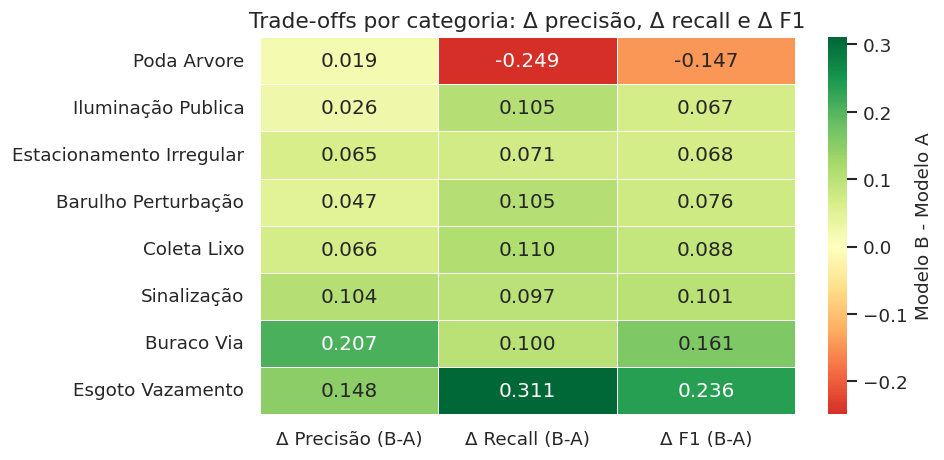

In [21]:
# Função para plotar heatmap dos deltas por categoria.
def plotar_heatmap_deltas_categoria(
    tabela: pd.DataFrame,
    nome_arquivo: str,
) -> None:
    """Plota um heatmap com deltas de precisão, recall e F1 por categoria.
    A escala centrada em zero destaca ganhos e perdas do Modelo B.
    """
    colunas_delta = ["Δ Precisão (B-A)", "Δ Recall (B-A)", "Δ F1 (B-A)"]
    dados = tabela.set_index("Categoria")[colunas_delta].sort_values("Δ F1 (B-A)")

    fig, ax = plt.subplots(figsize=(8, max(4, 0.45 * len(dados))))
    # Heatmap divergente: centro em zero para separar visualmente ganhos e perdas.
    sns.heatmap(dados, annot=True, fmt=".3f",
        cmap="RdYlGn", center=0, linewidths=0.5,
        cbar_kws={"label": "Modelo B - Modelo A"}, ax=ax)

    ax.set_title("Trade-offs por categoria: Δ precisão, Δ recall e Δ F1")
    ax.set_xlabel("")
    ax.set_ylabel("")
    save_figure(fig, fig_dir, nome_arquivo)

plotar_heatmap_deltas_categoria(
    tabela_categoria_ab,
    "07_heatmap_tradeoffs_categoria_modelo_b_menos_a",
)


**<u>Resultados</u>:**

- A maioria das categorias apresenta ganhos simultâneos de `Precisão`, `Recall` e `F1`.
- `esgoto_vazamento` concentra o maior ganho de `Recall`, com **+0,3108**, e também melhora `F1` em **+0,2359**.
- `poda_arvore` é o único trade-off claramente negativo: apesar de leve ganho de `Precisão` (**+0,0194**), há perda forte de `Recall` (**-0,2489**) e de `F1` (**-0,1471**).

⟹ O heatmap torna claro que o Modelo B melhora o desempenho geral, mas desloca parte do erro para `poda_arvore`. Essa categoria deve ser monitorada em qualquer plano de troca.

---


#### **2.3 Ganho Líquido por Categoria: Acertos, Recall e F1**

**Objetivo:** quantificar onde o Modelo B ganha ou perde em relação ao Modelo A por `categoria_real`.

**Metodologia:** calculamos três diferenças por categoria:

1. `ganho_liquido_b`: número de casos em que o B corrige o A menos casos em que o B cria erro.
2. `Δ Recall (B-A)`: diferença na capacidade de recuperar chamados reais da categoria.
3. `Δ F1 (B-A)`: diferença no equilíbrio entre precisão e recall.

Barras verdes indicam ganho do Modelo B; barras vermelhas indicam perda.

**Importância:** o ganho líquido em acertos mostra impacto operacional em número de chamados. `Recall` e `F1` mostram se esse ganho é consistente em métricas mais robustas ao desbalanceamento.

---


In [22]:
# Agrega os tipos de troca entre modelos por categoria real.
tabela_trocas_categoria = (
    df_comp.groupby("categoria_real")
    .agg(
        n=("id_chamado", "count"),
        ambos_acertam=("ambos_acertam", "sum"),
        ambos_erram=("ambos_erram", "sum"),
        a_acerta_b_erra=("a_acerta_b_erra", "sum"),
        b_acerta_a_erra=("b_acerta_a_erra", "sum"),
        confianca_media_a=("conf_modelo_a", "mean"),
        confianca_media_b=("conf_modelo_b", "mean"),
    ).reset_index()
)

tabela_trocas_categoria["Categoria"] = tabela_trocas_categoria["categoria_real"].map(pretty_label)
# Ganho líquido: correções feitas pelo B menos novos erros criados pelo B.
tabela_trocas_categoria["ganho_liquido_b"] = (
    tabela_trocas_categoria["b_acerta_a_erra"] - tabela_trocas_categoria["a_acerta_b_erra"]
)
tabela_trocas_categoria["ganho_liquido_b_pct"] = tabela_trocas_categoria["ganho_liquido_b"] / tabela_trocas_categoria["n"]
tabela_ganhos_categoria = tabela_trocas_categoria.merge(
    tabela_categoria_ab[["categoria_real", "Δ Recall (B-A)", "Δ F1 (B-A)"]], on="categoria_real", how="left")


In [23]:
# Função auxiliar para desenhar barras horizontais coloridas por sinal.
def plotar_barras_sinal(ax: plt.Axes, dados: pd.DataFrame, coluna_valor: str, titulo: str,
    xlabel: str, formato: str = "{:+.0f}") -> None:
    """Plota barras horizontais com verde para ganhos e vermelho para perdas.
    Os rótulos numéricos destacam a magnitude de cada diferença.
    """
    dados = dados.sort_values(coluna_valor)
    valores = dados[coluna_valor].to_numpy()
    cores = np.where(valores >= 0, "#2EAD4F", "#D64545")

    ax.barh(dados["Categoria"], valores, color=cores)
    ax.axvline(0, color="black", linewidth=1)
    ax.set_title(titulo, fontsize=14, pad=5)
    ax.set_xlabel(xlabel, fontsize=14, labelpad=10)
    ax.set_ylabel("")
    ax.grid(False)
    amplitude = valores.max() - valores.min()
    offset = 0.03 * amplitude if amplitude > 0 else 0.01
    ax.set_xlim(valores.min() - 7 * offset, valores.max() + 7 * offset)
    # Posiciona o rótulo à direita de ganhos e à esquerda de perdas.
    for i, valor in enumerate(valores):
        deslocamento = offset if valor >= 0 else -offset
        alinhamento = "left" if valor >= 0 else "right"

        ax.text(
            valor + deslocamento, i,
            formato.format(valor), va="center", ha=alinhamento)

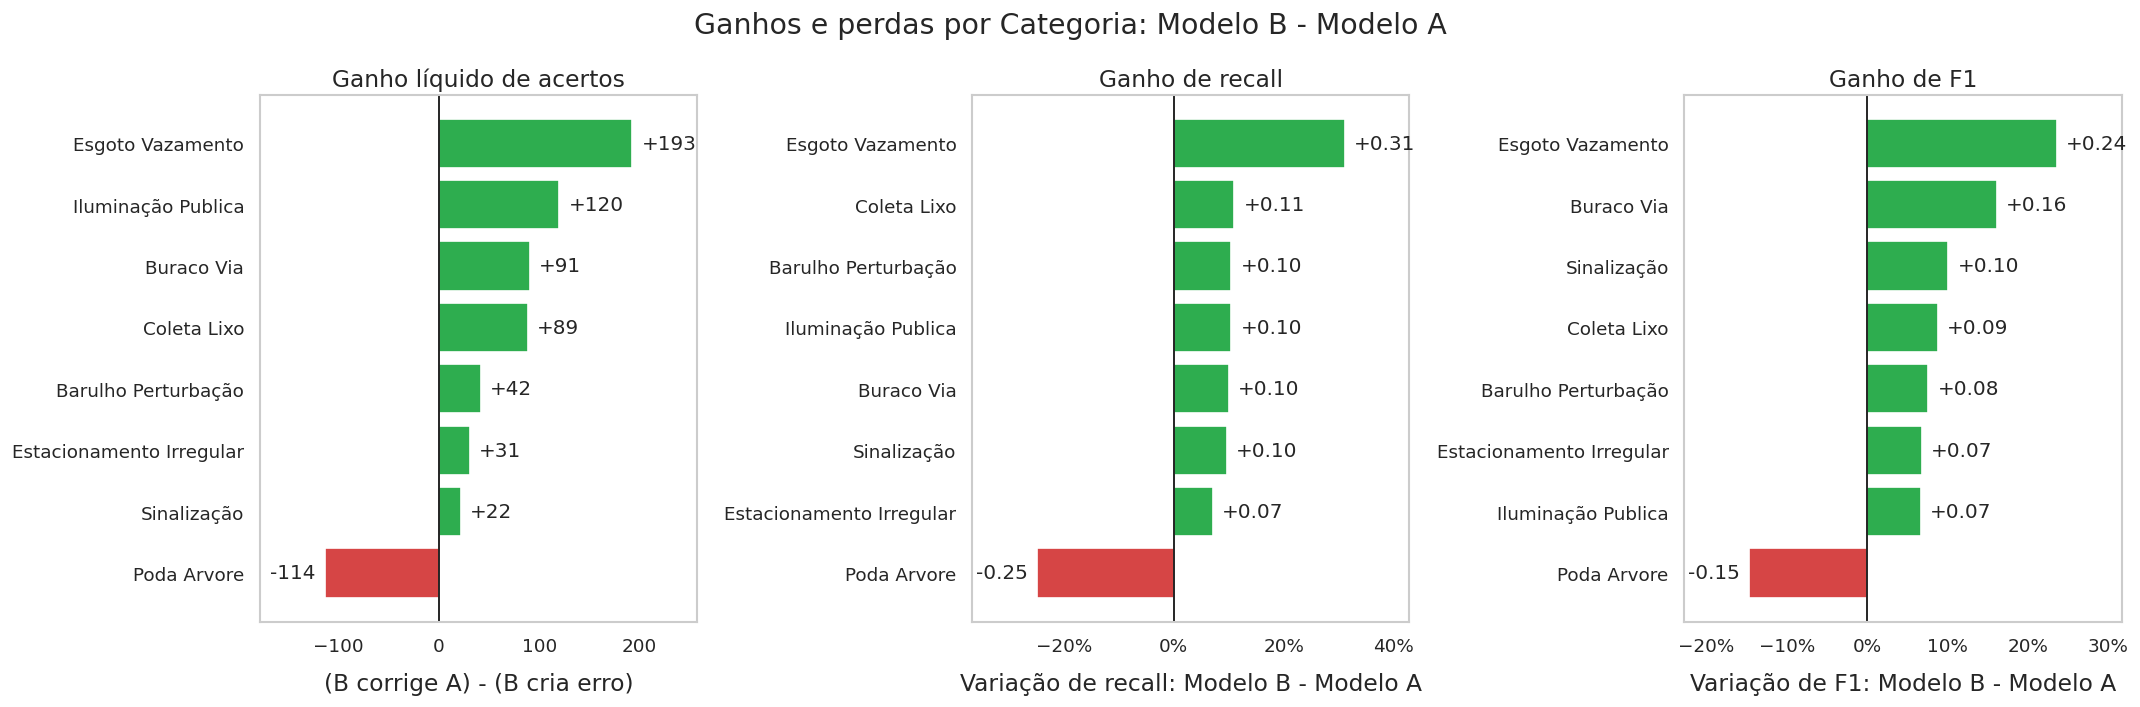

In [24]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
plotar_barras_sinal(
    axes[0], tabela_ganhos_categoria, "ganho_liquido_b",
    "Ganho líquido de acertos", "(B corrige A) - (B cria erro)",
    formato="{:+.0f}")

plotar_barras_sinal(
    axes[1], tabela_ganhos_categoria, "Δ Recall (B-A)",
    "Ganho de recall", "Variação de recall: Modelo B - Modelo A", formato="{:+.2f}")
axes[1].xaxis.set_major_formatter(mtick.PercentFormatter(1.0))

plotar_barras_sinal(
    axes[2], tabela_ganhos_categoria, "Δ F1 (B-A)",
    "Ganho de F1", "Variação de F1: Modelo B - Modelo A", formato="{:+.2f}")
axes[2].xaxis.set_major_formatter(mtick.PercentFormatter(1.0))

fig.suptitle("Ganhos e perdas por Categoria: Modelo B - Modelo A", fontsize=17)
fig.tight_layout()
save_figure(fig, fig_dir, "07_ganhos_acertos_recall_f1_por_categoria_modelo_b_menos_a")

**<u>Resultados</u>:**

- O Modelo B gera ganho líquido positivo em 7 das 8 categorias.

- O maior ganho absoluto ocorre em `esgoto_vazamento`, com cerca de **+193 acertos líquidos**, seguido por `iluminacao_publica` com **+120**, `buraco_via` com **+91** e `coleta_lixo` com **+89**.

- A única perda líquida relevante ocorre em `poda_arvore`, com aproximadamente **-114 acertos líquidos**.

- O mesmo padrão aparece em `Recall` e `F1`: `poda_arvore` perde recall e F1, enquanto as demais categorias melhoram.

⟹ A troca pelo Modelo B tem ganho operacional claro, mas exige ação específica para evitar degradação em chamados de `poda_arvore`.



### **3. Confusões, Confiança e Calibração**

#### **3.1 Matrizes de Confusão Comparadas**

**Objetivo:** comparar os padrões de erro dos Modelos A e B por `categoria_real` e categoria prevista.

**Metodologia:** construímos duas matrizes de confusão normalizadas por linha. Cada linha representa a categoria real e soma 1. Assim, a diagonal mostra o `Recall` de cada categoria e os valores fora da diagonal mostram para onde os chamados estão sendo desviados.

**Importância:** a matriz de confusão indica se o Modelo B apenas melhora a média ou se também reduz confusões operacionais relevantes, como encaminhar chamados de uma categoria para outra área de atendimento.

---


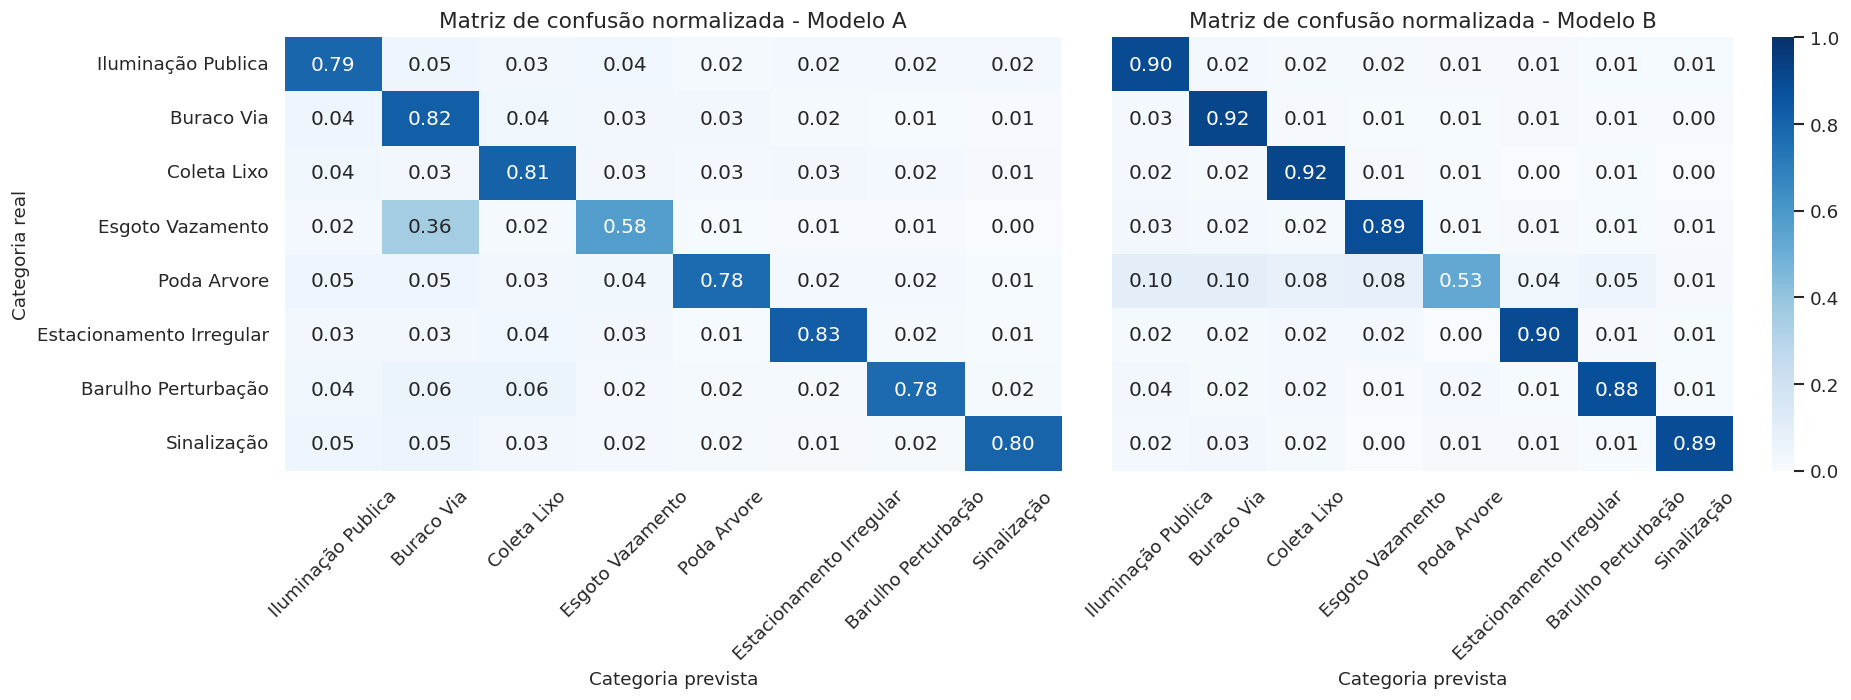

In [25]:
# Função para plotar matrizes de confusão normalizadas lado a lado.
def plotar_matrizes_confusao_comparadas(
    df: pd.DataFrame,
    labels: Sequence[Any],
    nome_arquivo: str,
) -> None:
    """Plota matrizes de confusão normalizadas dos Modelos A e B lado a lado.
    A normalização por linha permite ler cada diagonal como recall da categoria.
    """
    labels_pt = [pretty_label(label) for label in labels]
    matriz_a = confusion_matrix(
        df["categoria_real"],
        df["pred_modelo_a"],
        labels=labels,
        normalize="true",
    )
    matriz_b = confusion_matrix(
        df["categoria_real"],
        df["pred_modelo_b"],
        labels=labels,
        normalize="true",
    )

    fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=True)

    for ax, matriz, titulo in zip(
        axes,
        [matriz_a, matriz_b],
        ["Modelo A", "Modelo B"],
    ):
        sns.heatmap(
            matriz, annot=True, fmt=".2f", cmap="Blues", vmin=0, vmax=1,
            xticklabels=labels_pt, yticklabels=labels_pt, cbar=ax is axes[1], ax=ax)
        ax.set_title(f"Matriz de confusão normalizada - {titulo}")
        ax.set_xlabel("Categoria prevista")
        ax.set_ylabel("Categoria real" if ax is axes[0] else "")
        ax.tick_params(axis="x", rotation=45)
        ax.tick_params(axis="y", rotation=0)

    fig.tight_layout()
    save_figure(fig, fig_dir, nome_arquivo)


plotar_matrizes_confusao_comparadas(
    df_comp,
    classes,
    "07_matrizes_confusao_modelo_a_vs_b",
)


**<u>Resultados</u>:**

- No Modelo A, a diagonal de `esgoto_vazamento` era o principal ponto fraco: o recall dessa categoria era ≈ **0,5781**.

- No Modelo B, o recall de `esgoto_vazamento` sobe para ≈ **0,89**, <u>reduzindo uma confusão crítica observada na auditoria do Modelo A </u>.

- A matriz do Modelo B deve ser lida junto com o alerta de `poda_arvore`: apesar da melhora geral na diagonal, essa categoria tem queda de recall de ≈ **24,9 pontos percentuais**.

⟹ A matriz de confusão confirma que o Modelo B corrige confusões importantes, mas também evidencia o risco localizado em `poda_arvore`.


#### **3.2 Confiança do Modelo B em Acertos e Erros**

**Objetivo:** avaliar se `conf_modelo_b` separa melhor acertos e erros do que a confiança do Modelo A.

**Metodologia:** comparamos `conf_modelo_b` entre `acerto_modelo_b=True` e `acerto_modelo_b=False` por meio de tabela-resumo, boxplot e curvas de densidade. O boxplot mostra mediana, dispersão e cauda; a densidade mostra a distribuição completa da confiança.

**Importância:** se erros continuam recebendo confiança alta, o Modelo B pode melhorar a acurácia, mas ainda ser arriscado para automação sem revisão humana.

---


In [26]:
# Função para resumir e visualizar a confiança de um modelo separando acertos e erros.
def plotar_confianca_acertos_erros(df: pd.DataFrame, coluna_conf: str, coluna_acerto: str, nome_modelo: str, nome_arquivo: str) -> pd.DataFrame:
    """Resume e plota a confiança declarada em acertos e erros.
    Retorna tabela com média, mediana e quantis de confiança por resultado.
    """
    tabela = (
        df.groupby(coluna_acerto)
        .agg(
            n=("id_chamado", "count"),
            confianca_media=(coluna_conf, "mean"),
            confianca_mediana=(coluna_conf, "median"),
            confianca_p10=(coluna_conf, lambda x: x.quantile(0.10)),
            confianca_p90=(coluna_conf, lambda x: x.quantile(0.90)),
        )
        .reset_index()
    )
    tabela["resultado"] = tabela[coluna_acerto].map({True: "Acertos", False: "Erros"})

    dados_plot = df.copy()
    dados_plot["Resultado"] = dados_plot[coluna_acerto].map({True: "Acertos", False: "Erros"})

    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    # Boxplot compara posição e dispersão da confiança em erros e acertos.
    sns.boxplot(
        data=dados_plot, x="Resultado", y=coluna_conf, order=["Erros", "Acertos"],
        ax=axes[0], color="#76A7DC")
    axes[0].set_title(f"Confiança em acertos e erros ({nome_modelo})")
    axes[0].set_xlabel("Resultado da predição")
    axes[0].set_ylabel("Confiança declarada")
    axes[0].set_ylim(0, 1)

    # Densidade compara o formato completo das distribuições de confiança.
    sns.kdeplot(data=dados_plot, x=coluna_conf, hue="Resultado", hue_order=["Erros", "Acertos"],
        palette=["#F00031", "#00BE1D"], common_norm=False, fill=False, linewidth=2, ax=axes[1],)
    axes[1].set_title(f"Distribuição da confiança declarada ({nome_modelo})")
    axes[1].set_xlabel("Confiança declarada")
    axes[1].set_ylabel("Densidade")
    axes[1].set_xlim(0, 1)
    fig.tight_layout()
    save_figure(fig, fig_dir, nome_arquivo)
    return tabela


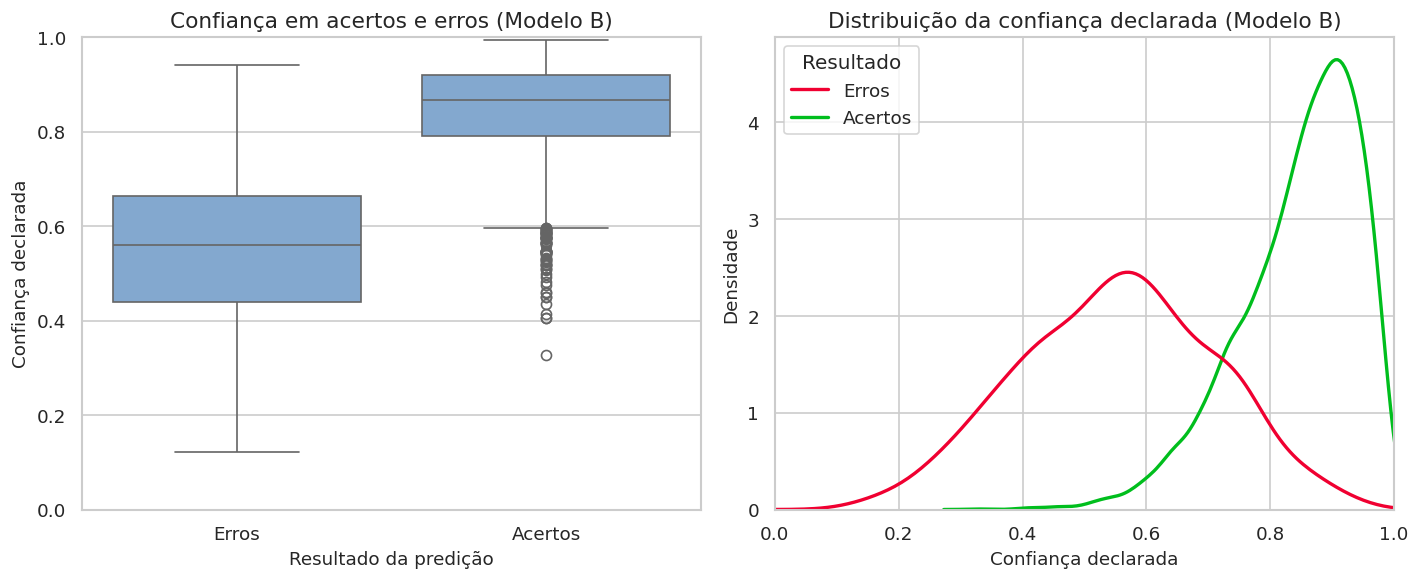

,acerto_modelo_b,n,confianca_media,confianca_mediana,confianca_p10,confianca_p90,resultado
0,False,662,0.552995,0.5595,0.3460,0.7527,Erros
1,True,4338,0.846269,0.8660,0.7117,0.9543,Acertos


PosixPath('../results/tables/comparacao_de_modelos/07_confianca_por_acerto_erro_modelo_b.csv')

In [27]:
# Avalia a confiança do Modelo B em acertos e erros.
tabela_confianca_modelo_b = plotar_confianca_acertos_erros(
    df_comp,
    coluna_conf="conf_modelo_b",
    coluna_acerto="acerto_modelo_b",
    nome_modelo="Modelo B",
    nome_arquivo="07_confianca_acertos_erros_modelo_b",
)

display(tabela_confianca_modelo_b)
save_table(tabela_confianca_modelo_b, tab_dir, "07_confianca_por_acerto_erro_modelo_b")

**<u>Resultados</u>:**

- A tabela acima deve ser usada para comparar `confianca_media`, `confianca_mediana`, `confianca_p10` e `confianca_p90` entre erros e acertos do Modelo B.

- Se as curvas de erros e acertos ficarem muito sobrepostas, `conf_modelo_b` não separa bem casos confiáveis de casos duvidosos, mesmo que o Modelo B tenha maior acurácia.

- Se a curva de erros se deslocar claramente para valores menores, a confiança do Modelo B é operacionalmente mais útil para triagem e revisão humana.

⟹ Essa análise complementa a acurácia: um modelo melhor pode ainda precisar de calibração antes de decisões automáticas baseadas em confiança.



#### **3.3 Curvas de Calibração Aproximada: Modelo A vs Modelo B**

**Objetivo:** comparar se `conf_modelo_a` e `conf_modelo_b` estão alinhadas com a acurácia observada.

**Metodologia:** para cada modelo:

1. agrupamos os chamados por faixas de confiança (`faixa_confianca_a` ou `faixa_confianca_b`);
2. calculamos a confiança média declarada em cada faixa;
3. calculamos a acurácia observada na mesma faixa;
4. comparamos cada ponto com a diagonal de calibração perfeita.

Também calculamos o ECE aproximado:

$$
\text{ECE} = \sum_k w_k\, |\text{confiança média}_k - \text{acurácia observada}_k|
$$

em que $w_k$ é o peso da faixa de confiança $k$. ECE mais próximo de zero indica melhor calibração.

**Importância:** Se o Modelo B for mais acurado, mas mal calibrado, a confiança ainda deve ser usada com cautela em automação e priorização.

---


In [28]:
# Função para calcular curva de calibração aproximada e ECE.
def calcular_curva_calibracao(df: pd.DataFrame, coluna_faixa: str, coluna_conf: str, coluna_acerto: str) -> Tuple[pd.DataFrame, float]:
    """Calcula confiança média, acurácia observada e ECE por faixa de confiança.
    O ECE resume o desalinhamento médio ponderado entre confiança e acerto real.
    """
    
    tabela = (
        df.groupby(coluna_faixa, observed=False)
        .agg(
            n=("id_chamado", "count"),
            confianca_media=(coluna_conf, "mean"),
            acuracia_observada=(coluna_acerto, "mean"),
        )
        .reset_index()
    )

    # Remove faixas vazias para evitar pontos sem significado no gráfico.
    tabela = tabela.loc[tabela["n"] > 0].copy()
    tabela["gap_calibracao"] = tabela["confianca_media"] - tabela["acuracia_observada"]
    tabela["peso"] = tabela["n"] / tabela["n"].sum()
    ece = float((tabela["peso"] * tabela["gap_calibracao"].abs()).sum())

    return tabela, ece


In [29]:
# Calcula curvas e ECE para os dois modelos.
tabela_calibracao_a, ece_a = calcular_curva_calibracao(
    df_comp, coluna_faixa="faixa_confianca_a", coluna_conf="conf_modelo_a", coluna_acerto="acerto_modelo_a")

tabela_calibracao_b, ece_b = calcular_curva_calibracao(
    df_comp, coluna_faixa="faixa_confianca_b", coluna_conf="conf_modelo_b", coluna_acerto="acerto_modelo_b")

print(f"ECE aproximado - Modelo A: {ece_a:.4f}")
print(f"ECE aproximado - Modelo B: {ece_b:.4f}")

ECE aproximado - Modelo A: 0.1517
ECE aproximado - Modelo B: 0.1195


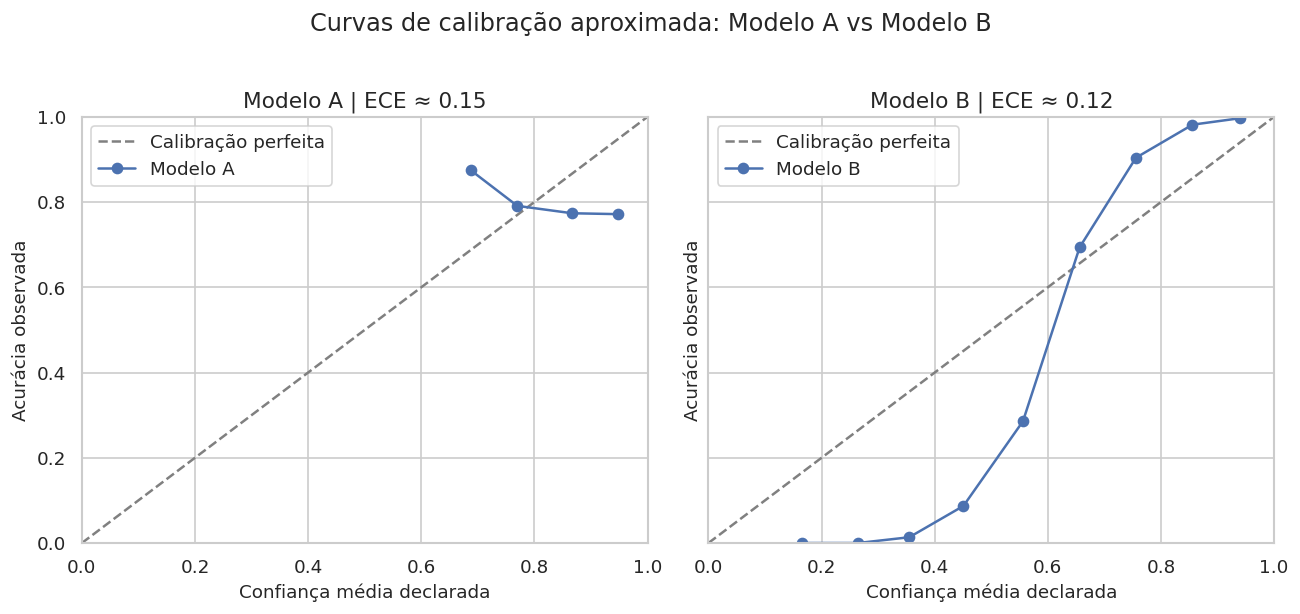

In [30]:
# Plota as curvas de calibração aproximada dos dois modelos lado a lado.
fig, axes = plt.subplots(1, 2, figsize=(11, 5), sharex=True, sharey=True)
for ax, tabela, modelo, ece in [
    (axes[0], tabela_calibracao_a, "Modelo A", ece_a),
    (axes[1], tabela_calibracao_b, "Modelo B", ece_b),
]:
    # Linha diagonal: confiança média igual à acurácia observada.
    ax.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Calibração perfeita")
    ax.plot(
        tabela["confianca_media"], tabela["acuracia_observada"],
        marker="o", label=modelo)
    ax.set_title(f"{modelo} | ECE ≈ {ece:.2f}")
    ax.set_xlabel("Confiança média declarada")
    ax.set_ylabel("Acurácia observada")
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.legend()

fig.suptitle("Curvas de calibração aproximada: Modelo A vs Modelo B", y=1.02)
fig.tight_layout()
save_figure(fig, fig_dir, "07_curvas_calibracao_modelo_a_vs_b")


**<u>Resultados</u>:**

- O ECE do Modelo A deve ser comparado diretamente com o ECE do Modelo B: menor ECE indica melhor alinhamento entre confiança declarada e acurácia observada.
- Pontos abaixo da diagonal indicam excesso de confiança; pontos acima indicam subconfiança.
- A comparação lado a lado permite verificar se o Modelo B melhora apenas a acurácia ou se também melhora a confiabilidade do score `conf_modelo_b`.

⟹ Se o Modelo B tiver ECE menor e curva mais próxima da diagonal, ele é mais adequado para uso com limiares de confiança. Se não tiver, a troca ainda pode ser recomendada por desempenho, mas com calibração posterior ou revisão humana em faixas de risco.

[mudar aqui]

---


### **4. Robustez da Troca por Subgrupos**

#### **4.1 Diferença de Acurácia por Canal, Tamanho do Texto e Bairro**

**Objetivo:** verificar se o ganho do Modelo B é homogêneo em subgrupos operacionais além de `categoria_real`.

**Metodologia:** para cada grupo em `canal`, `faixa_tamanho_texto` e `bairro`, calculamos:

$$
\Delta \text{Acurácia} = \text{Acurácia}_B - \text{Acurácia}_A
$$

Também aplicamos McNemar em cada grupo, pois a comparação continua pareada dentro de cada subgrupo. Para evitar ruído, ignoramos grupos com suporte muito pequeno.

**Importância:** uma troca de modelo pode ser globalmente positiva, mas gerar perda em canais ou territórios específicos. Essa análise ajuda a antecipar riscos de implantação.

---


In [37]:
# Função para comparar acurácia pareada por subgrupo.
def comparar_acuracia_por_grupo(df: pd.DataFrame, coluna_grupo: str, min_n: int = 30) -> pd.DataFrame:
    """Calcula diferença de acurácia B-A e McNemar por grupo.
    Grupos com menos de min_n chamados são removidos para reduzir instabilidade.
    """
    linhas: List[Dict[str, Any]] = []

    for grupo, dados in df.groupby(coluna_grupo, dropna=False):
        if len(dados) < min_n:
            continue

        teste = executar_mcnemar(dados["acerto_modelo_a"], dados["acerto_modelo_b"])
        acc_a = dados["acerto_modelo_a"].mean()
        acc_b = dados["acerto_modelo_b"].mean()

        linhas.append({
            "variavel": coluna_grupo,
            "grupo": grupo,
            "grupo_pt": pretty_label(grupo),
            "n": len(dados),
            "accuracy_a": acc_a,
            "accuracy_b": acc_b,
            "delta_accuracy_b_menos_a": acc_b - acc_a,
            "A acerta, B erra": teste["A acerta, B erra"],
            "B acerta, A erra": teste["B acerta, A erra"],
            "Ganho Líquido B": teste["Ganho Líquido B"],
            "P-valor Mcnemar": teste["P-valor"],
            "Método Mcnemar": teste["Método"],
        })

    tabela = pd.DataFrame(linhas)

    if not tabela.empty:
        tabela["p_valor_mcnemar_ajustado_bh"] = multipletests(
            tabela["P-valor Mcnemar"].fillna(1),
            method="fdr_bh")[1]

    return tabela.sort_values("delta_accuracy_b_menos_a")

# Função para plotar diferenças de acurácia por subgrupo.
def plotar_delta_accuracy_grupo(tabela: pd.DataFrame, titulo: str, nome_arquivo: str, top_n: Optional[int] = None) -> None:
    """Plota diferença de acurácia B-A por grupo com barras coloridas por sinal.
    Para listas longas, exibe apenas os maiores ganhos e perdas.
    """
    dados = tabela.copy()

    if top_n is not None:
        dados = pd.concat([dados.head(top_n), dados.tail(top_n)]).drop_duplicates()

    dados = dados.sort_values("delta_accuracy_b_menos_a")
    cores = np.where(dados["delta_accuracy_b_menos_a"] >= 0, "#2EAD4F", "#D64545")

    fig, ax = plt.subplots(figsize=(6, max(3, 0.3 * len(dados))))
    ax.barh(dados["grupo_pt"], dados["delta_accuracy_b_menos_a"], color=cores)
    ax.axvline(0, color="black", linewidth=1)
    ax.set_title(titulo)
    ax.set_xlabel("Diferença de acurácia: Modelo B - Modelo A")
    ax.set_ylabel("")
    ax.xaxis.set_major_formatter(mtick.PercentFormatter(1.0))
    save_figure(fig, fig_dir, nome_arquivo)


# Calcula as comparações por dimensões operacionais.
tabela_comp_canal = comparar_acuracia_por_grupo(df_comp, "canal", min_n=30)
tabela_comp_tamanho = comparar_acuracia_por_grupo(df_comp, "faixa_tamanho_texto", min_n=30)
tabela_comp_bairro = comparar_acuracia_por_grupo(df_comp, "bairro", min_n=50)

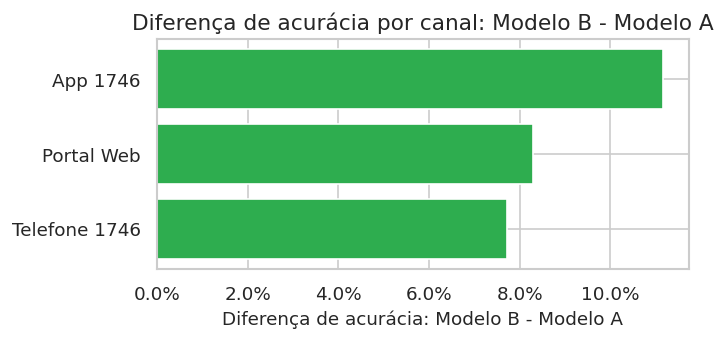

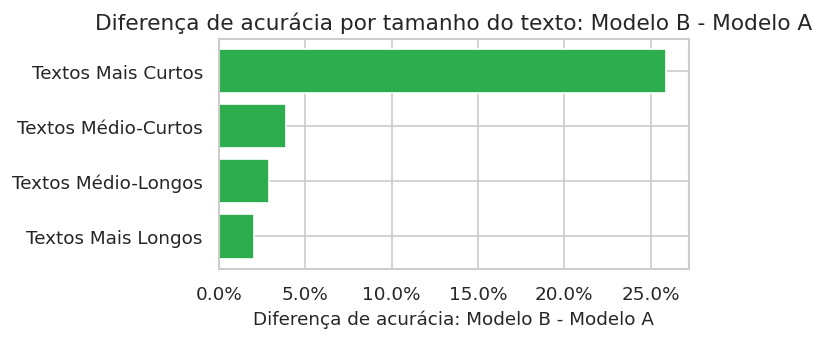

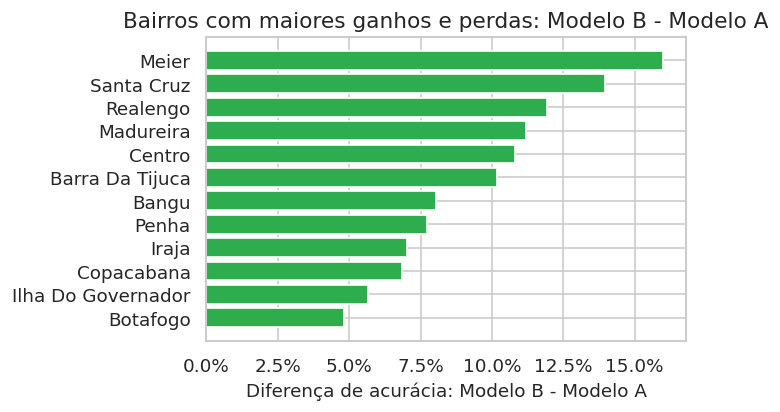

In [38]:
# Plota a diferença de acurácia por canal de entrada.
plotar_delta_accuracy_grupo(
    tabela_comp_canal,
    "Diferença de acurácia por canal: Modelo B - Modelo A",
    "07_delta_accuracy_por_canal_modelo_b_menos_a",
)

# Plota a diferença de acurácia por faixa de tamanho textual.
plotar_delta_accuracy_grupo(
    tabela_comp_tamanho,
    "Diferença de acurácia por tamanho do texto: Modelo B - Modelo A",
    "07_delta_accuracy_por_tamanho_texto_modelo_b_menos_a",
)

# Para bairros, mostra apenas maiores ganhos e maiores perdas para evitar gráfico poluído.
plotar_delta_accuracy_grupo(
    tabela_comp_bairro,
    "Bairros com maiores ganhos e perdas: Modelo B - Modelo A",
    "07_delta_accuracy_por_bairro_modelo_b_menos_a",
    top_n=6,
)


**<u>Resultados</u>:**

- A tabela de `canal` indica se o ganho do Modelo B aparece de forma consistente entre app, telefone e portal.
- A tabela de `faixa_tamanho_texto` mostra se o Modelo B melhora especialmente textos curtos, médios ou longos.
- A análise por `bairro` deve ser interpretada com mais cautela, pois mesmo com `min_n=50`, diferenças locais podem refletir composição de categorias e vocabulário específico.

⟹ Essa etapa verifica se a melhora do Modelo B é operacionalmente distribuída ou se há subgrupos que exigem monitoramento após implantação.

[mudar aqui]


---
---

### **5. Achados mais Relevantes**

1. **O Modelo B melhora claramente o desempenho global.**  
   A `Acurácia` sobe de ≈ 0,77 para ≈ 0,86, um ganho de 9,48 pontos percentuais. O `F1 Macro` também sobe de ≈ 0,77 para ≈ 0,85, com IC 95% do ganho inteiramente acima de zero: **[0,0648; 0,0978]**.

2. **A melhora não depende apenas das classes majoritárias.**  
   Métricas robustas ao desbalanceamento também melhoram: `Recall Macro` aumenta ≈ 0,08, `Kappa de Cohen` aumenta ≈ 0,11 e `Coeficiente de Matthews` aumenta ≈ 0,11. Isso indica que o ganho do Modelo B não é apenas efeito de acertar melhor categorias frequentes.

3. **O Modelo B corrige uma fragilidade crítica do Modelo A em `esgoto_vazamento`.**  
   O `Recall` de `esgoto_vazamento` aumenta cerca de **31,1 pontos percentuais**, saindo de aproximadamente ≈ **0,58** para ≈ **0,89**. Essa mudança reduz risco de encaminhamento incorreto em dessa categoria.

4. **O principal trade-off é `poda_arvore`.**  
   Nessa categoria, o Modelo B melhora levemente a `Precisão` (≈ **+0,02**), mas reduz fortemente o `Recall` (≈ **-0,25**) e o `F1` (≈ **-0,15**). Em termos operacionais, isso significa que mais chamados reais de `poda_arvore` deixam de ser identificados corretamente.

5. **A troca exige monitoramento da confiança e calibração.**  
   A comparação das curvas de calibração mostra se `conf_modelo_b` pode ser usada em automação. Caso o ECE do Modelo B não seja baixo, a confiança deve ser calibrada ou usada apenas como sinal auxiliar, não como regra automática isolada.



---

### **6. Recomendação para Gestor**

A recomendação é **avançar com a substituição do Modelo A pelo Modelo B, mas com implantação controlada e mitigação específica para a categoria `poda_arvore`**. O Modelo B apresenta melhora global relevante: acerta cerca de **474 chamados a mais** em uma base de **5.000**, melhora o `F1 Macro` em cerca de **8,1 pontos percentuais** e corrige uma falha importante em `esgoto_vazamento`. O risco principal é que o Modelo B piora a identificação de chamados de `poda_arvore`, com queda de aproximadamente **24,9 pontos percentuais** em `Recall`. Portanto, a troca deve vir acompanhada de monitoramento diário por categoria, revisão humana temporária para chamados que possam envolver poda de árvore, calibração da confiança declarada e plano de rollback caso a perda nessa categoria se confirme em produção.
